# 02 – Clustering et analyse non supervisée

**Auteur :** Grégory CRESPIN  
**Projet :** Labellisez et appliquez des approches semi-supervisées en traitement d'images  
**Nom court :** BrainScanAI  
**Date :** 08/02/2026

Objectifs :
1. Réduire la dimensionnalité (PCA, t-SNE) pour la visualisation.
2. Appliquer des algorithmes de clustering (K-Means, DBSCAN) avec 2 groupes.
3. Évaluer via le score ARI sur les données **fortement** labellisées uniquement.
4. Produire un jeu **faiblement** labellisé (labels issus du clustering) en le **gardant séparé** du jeu fortement labellisé.

In [1]:
# sys : modifier le chemin de recherche des modules
import sys
# Path : manipulation des chemins de fichiers
from pathlib import Path
# numpy : calculs numériques
import numpy as np
# pandas : manipulation de données structurées
import pandas as pd
# matplotlib : graphiques
import matplotlib.pyplot as plt
# seaborn : graphiques statistiques plus beaux
import seaborn as sns

# StandardScaler : normalisation des données (moyenne=0, écart-type=1)
from sklearn.preprocessing import StandardScaler
# PCA : réduction de dimensionnalité linéaire
from sklearn.decomposition import PCA
# TSNE : réduction de dimensionnalité non-linéaire pour visualisation
from sklearn.manifold import TSNE
# KMeans : algorithme de clustering par centroïdes
from sklearn.cluster import KMeans, DBSCAN
# adjusted_rand_score : métrique pour comparer les clusters aux vrais labels
from sklearn.metrics import adjusted_rand_score, silhouette_score

# Ajouter le répertoire courant au chemin Python
sys.path.insert(0, str(Path.cwd()))
# Importer la configuration
import config
import umap
# Éviter l'avertissement UMAP "n_jobs overridden by random_state"
import warnings
warnings.filterwarnings("ignore", message=".*n_jobs.*random_state.*", category=UserWarning, module="umap")

## 1. Chargement des features et standardisation

In [2]:
# Charger les features sauvegardées dans le notebook 01
# np.load() charge un fichier .npy (tableau numpy sauvegardé)
X_labeled = np.load(config.FEATURES_DIR / "features_labeled.npy")
X_unlabeled = np.load(config.FEATURES_DIR / "features_unlabeled.npy")

# Charger les labels correspondants depuis le CSV
# pd.read_csv() lit un fichier CSV et crée un DataFrame
df_labeled = pd.read_csv(config.FEATURES_DIR / "labels_labeled.csv")

# Convertir les labels texte (normal, cancer) en nombres (0, 1)
# map() applique une fonction à chaque élément de la colonne
# CLASS_TO_IDX = {"normal": 0, "cancer": 1}
y_true = df_labeled["label"].map(config.CLASS_TO_IDX).values
# .values convertit la série pandas en tableau numpy

# Standardiser les features
# StandardScaler : transforme les données pour avoir moyenne=0 et écart-type=1
# Pourquoi ? Les algorithmes de clustering sont sensibles à l'échelle des données
scaler = StandardScaler()
# fit_transform() : calcule la moyenne et l'écart-type sur les données labellisées, puis normalise
X_labeled_std = scaler.fit_transform(X_labeled)
# transform() : applique la même normalisation (même moyenne/écart-type) aux données non labellisées
X_unlabeled_std = scaler.transform(X_unlabeled)

print("Données fortement labellisées:", X_labeled_std.shape, "| labels:", y_true.shape)
print("Données non labellisées:", X_unlabeled_std.shape)

Données fortement labellisées: (100, 1024) | labels: (100,)
Données non labellisées: (1406, 1024)


## 2. Réduction de dimensionnalité (PCA, t-SNE)

In [3]:
# PCA : Principal Component Analysis
# Réduit la dimensionnalité en gardant les directions de plus grande variance
# n_components=50 : garder les 50 premières composantes principales
pca = PCA(n_components=50, random_state=config.RANDOM_STATE)
# random_state : pour avoir des résultats reproductibles

# fit_transform() : apprend la transformation sur les données labellisées
X_labeled_pca = pca.fit_transform(X_labeled_std)
# transform() : applique la même transformation aux données non labellisées
X_unlabeled_pca = pca.transform(X_unlabeled_std)

# explained_variance_ratio_ : proportion de variance expliquée par chaque composante
# .sum() : variance totale expliquée par les 50 premières composantes
print("Variance expliquée (50 composantes):", pca.explained_variance_ratio_.sum().round(4))

# t-SNE : t-Distributed Stochastic Neighbor Embedding
# Réduction non-linéaire pour visualisation en 2D
# perplexity=30 : nombre de voisins à considérer (plus grand = plus global)
tsne = TSNE(n_components=2, random_state=config.RANDOM_STATE, perplexity=30)

# Appliquer t-SNE sur les données PCA (on réduit encore plus)
# On prend seulement les 30 premières composantes PCA pour accélérer
X_labeled_tsne = tsne.fit_transform(X_labeled_pca[:, :min(30, X_labeled_pca.shape[1])])
X_unlabeled_tsne = tsne.fit_transform(X_unlabeled_pca[:, :min(30, X_unlabeled_pca.shape[1])])

# UMAP : Uniform Manifold Approximation and Projection
# Réduction de dimensionnalité non-linéaire alternative à t-SNE
# n_neighbors=15 : nombre de voisins pour construire le graphe
# min_dist=0.1 : distance minimale entre les points dans l'espace réduit
# n_jobs=1 : explicite (reproductibilité avec random_state)
reducer = umap.UMAP(
    n_components=2,
    random_state=config.RANDOM_STATE,
    n_neighbors=15,
    min_dist=0.1,
    n_jobs=1,
)

# Appliquer UMAP sur les données PCA (mêmes 30 premières composantes)
X_labeled_umap = reducer.fit_transform(X_labeled_pca[:, :min(30, X_labeled_pca.shape[1])])
X_unlabeled_umap = reducer.transform(X_unlabeled_pca[:, :min(30, X_unlabeled_pca.shape[1])])

Variance expliquée (50 composantes): 0.9124


## 3. Clustering (K-Means et DBSCAN)

In [4]:
# K-Means : algorithme de clustering qui divise les données en K groupes
# n_clusters=2 : on veut 2 groupes (normal et cancer)
# random_state : pour reproductibilité
# n_init=10 : exécuter 10 fois avec des initialisations différentes, garder le meilleur
kmeans = KMeans(n_clusters=config.N_CLUSTERS, random_state=config.RANDOM_STATE, n_init=10)

# fit_predict() : apprend les clusters sur les données labellisées et assigne chaque point à un cluster
kmeans_labeled = kmeans.fit_predict(X_labeled_std)


from sklearn.metrics import confusion_matrix

# Appliquer K-Means
kmeans = KMeans(n_clusters=config.N_CLUSTERS, random_state=config.RANDOM_STATE, n_init=10)
kmeans_labeled = kmeans.fit_predict(X_labeled_std)
kmeans_unlabeled = kmeans.predict(X_unlabeled_std)

# Créer une matrice de confusion pour voir la correspondance
# confusion_matrix(y_true, kmeans_labeled) montre combien de points de chaque vraie classe
# sont dans chaque cluster
cm = confusion_matrix(y_true, kmeans_labeled)
print("Matrice de confusion (vrais labels vs clusters K-Means):")
print("         Cluster 0  Cluster 1")
print(f"Normal:    {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"Cancer:    {cm[1,0]:4d}      {cm[1,1]:4d}")
print()

# Déterminer le mapping correct
# Si la majorité des "normal" (y_true=0) sont dans le cluster 0 de K-Means,
# alors cluster 0 = normal, sinon cluster 1 = normal
if cm[0, 0] + cm[1, 1] > cm[0, 1] + cm[1, 0]:
    # Pas d'inversion : cluster 0 = normal (0), cluster 1 = cancer (1)
    mapping = {0: 0, 1: 1}
    print("Mapping détecté : Cluster 0 → Normal, Cluster 1 → Cancer")
else:
    # Inversion détectée : cluster 0 = cancer (1), cluster 1 = normal (0)
    mapping = {0: 1, 1: 0}
    print("Mapping détecté : Cluster 0 → Cancer, Cluster 1 → Normal (inversion corrigée)")
    print()

# Appliquer le mapping pour corriger les labels
# np.vectorize() crée une fonction qui applique le mapping à chaque élément
map_func = np.vectorize(lambda x: mapping[x])
kmeans_labeled_corrected = map_func(kmeans_labeled)
kmeans_unlabeled_corrected = map_func(kmeans_unlabeled)

# Vérifier que c'est mieux aligné maintenant
ari_kmeans_corrected = adjusted_rand_score(y_true, kmeans_labeled_corrected)
print(f"ARI avant correction: {adjusted_rand_score(y_true, kmeans_labeled):.4f}")
print(f"ARI après correction: {ari_kmeans_corrected:.4f}")
print()

# Utiliser les labels corrigés pour la suite
kmeans_labeled = kmeans_labeled_corrected
kmeans_unlabeled = kmeans_unlabeled_corrected

# Recalculer les métriques avec les labels corrigés
ari_kmeans = adjusted_rand_score(y_true, kmeans_labeled)
sil_kmeans = silhouette_score(X_labeled_std, kmeans_labeled)

print("K-Means – ARI (données fortement labellisées):", round(ari_kmeans, 4))
print("K-Means – Silhouette:", round(sil_kmeans, 4))



Matrice de confusion (vrais labels vs clusters K-Means):
         Cluster 0  Cluster 1
Normal:       2        48
Cancer:      45         5

Mapping détecté : Cluster 0 → Cancer, Cluster 1 → Normal (inversion corrigée)

ARI avant correction: 0.7370
ARI après correction: 0.7370

K-Means – ARI (données fortement labellisées): 0.737
K-Means – Silhouette: 0.1227


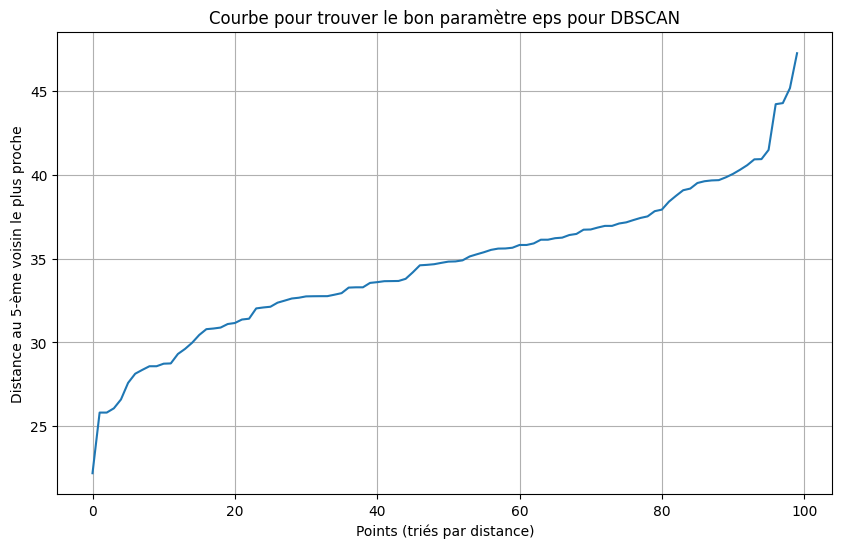

eps suggéré (percentile 75): 37.105
DBSCAN – nombre de clusters (labeled): 1 | ARI: N/A


In [5]:

from sklearn.neighbors import NearestNeighbors

# Calculer les distances aux k-plus proches voisins
k = 5  # min_samples
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_labeled_std)
distances, indices = neighbors_fit.kneighbors(X_labeled_std)

# Trier les distances et prendre la k-ième distance
distances = np.sort(distances, axis=0)
distances = distances[:, k-1]  # k-ème voisin

# Visualiser pour trouver le "coude" (bon eps)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(np.sort(distances))
plt.xlabel('Points (triés par distance)')
plt.ylabel(f'Distance au {k}-ème voisin le plus proche')
plt.title('Courbe pour trouver le bon paramètre eps pour DBSCAN')
plt.grid(True)
plt.show()

# Suggérer un eps
eps_suggested = np.percentile(distances, 75)
print(f"eps suggéré (percentile 75): {eps_suggested:.3f}")

# DBSCAN : Density-Based Spatial Clustering
# Trouve des clusters basés sur la densité de points
# eps=Utiliser l'eps suggéré : distance maximale entre deux points pour être dans le même cluster
# min_samples=5 : nombre minimum de points pour former un cluster
dbscan = DBSCAN(eps=eps_suggested, min_samples=5)

# fit_predict() : trouve les clusters
# Retourne -1 pour les points considérés comme bruit (outliers)
dbscan_labeled = dbscan.fit_predict(X_labeled_std)
dbscan_unlabeled = dbscan.fit_predict(X_unlabeled_std)

# Compter le nombre de clusters (en excluant le bruit -1)
# set() : ensemble unique des valeurs
# len() : nombre de clusters
n_db = len(set(dbscan_labeled)) - (1 if -1 in dbscan_labeled else 0)

# Calculer l'ARI seulement si on a exactement 2 clusters (comme attendu)
ari_db = adjusted_rand_score(y_true, dbscan_labeled) if n_db == 2 else np.nan

print("DBSCAN – nombre de clusters (labeled):", n_db, "| ARI:", round(ari_db, 4) if not np.isnan(ari_db) else "N/A")

## 4. Visualisation des clusters (données fortement labellisées)

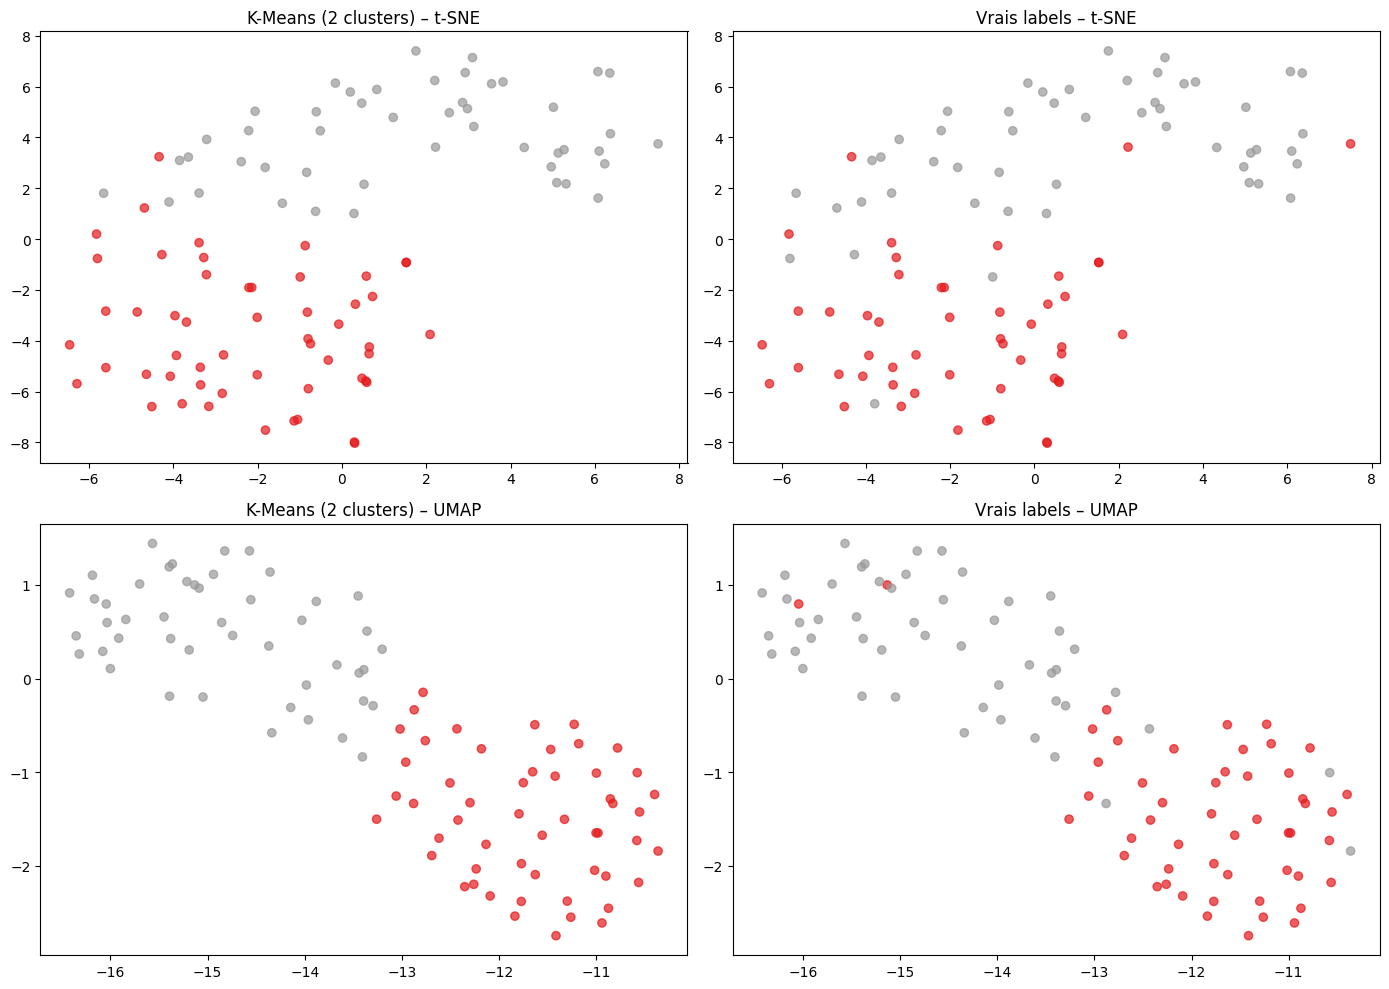

In [6]:

# Créer une figure avec 4 sous-graphiques (2x2) : t-SNE en haut, UMAP en bas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Graphique 1 : Visualiser les clusters K-Means en 2D (t-SNE)
# scatter() : nuage de points
# c=kmeans_labeled : couleur selon le cluster assigné
# cmap="Set1" : palette de couleurs
# alpha=0.7 : transparence (70% opaque)
axes[0, 0].scatter(X_labeled_tsne[:, 0], X_labeled_tsne[:, 1], c=kmeans_labeled, cmap="Set1", alpha=0.7)
axes[0, 0].set_title("K-Means (2 clusters) – t-SNE")

# Graphique 2 : Visualiser les vrais labels en 2D (t-SNE)
axes[0, 1].scatter(X_labeled_tsne[:, 0], X_labeled_tsne[:, 1], c=y_true, cmap="Set1", alpha=0.7)
axes[0, 1].set_title("Vrais labels – t-SNE")

# Graphique 3 : Visualiser les clusters K-Means en 2D (UMAP)
axes[1, 0].scatter(X_labeled_umap[:, 0], X_labeled_umap[:, 1], c=kmeans_labeled, cmap="Set1", alpha=0.7)
axes[1, 0].set_title("K-Means (2 clusters) – UMAP")

# Graphique 4 : Visualiser les vrais labels en 2D (UMAP)
axes[1, 1].scatter(X_labeled_umap[:, 0], X_labeled_umap[:, 1], c=y_true, cmap="Set1", alpha=0.7)
axes[1, 1].set_title("Vrais labels – UMAP")

# Ajuster l'espacement
plt.tight_layout()
# Afficher
plt.show()

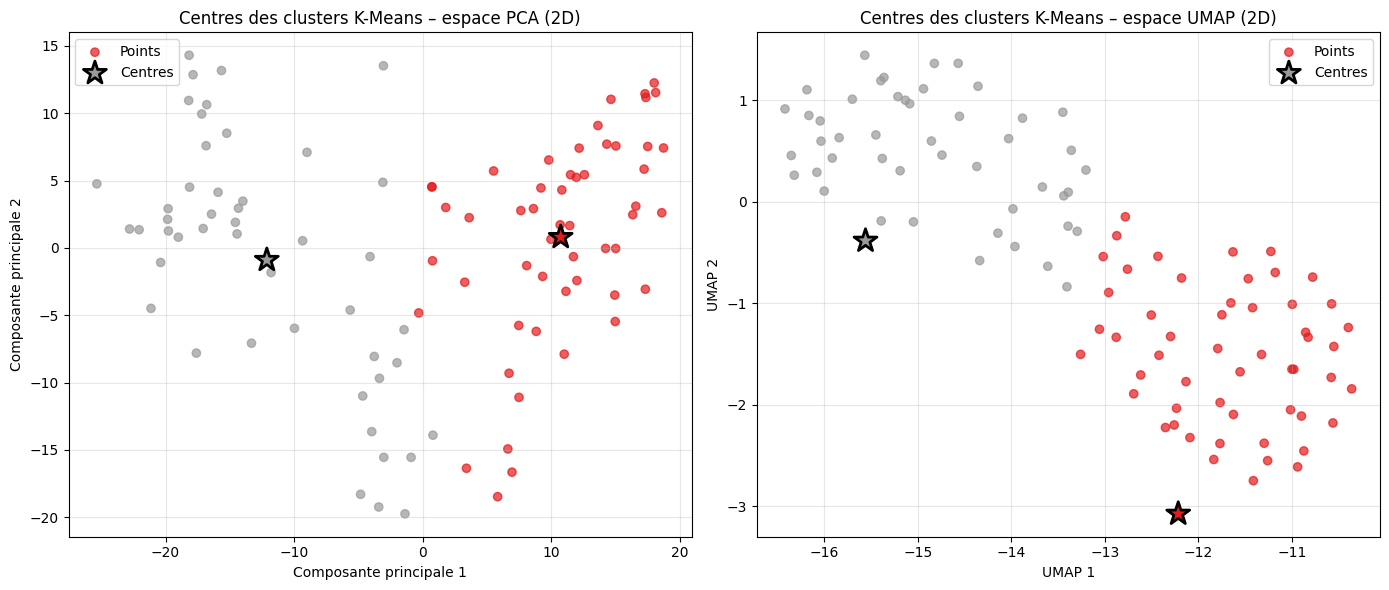

In [7]:
# Visualisation des centres (centroïdes) de chaque cluster K-Means
# Les centres sont dans l'espace des features standardisées ; on les projette en 2D (PCA et UMAP)
# pour les superposer aux nuages de points.

# Centres dans l'espace PCA (50 composantes), puis 2 premières pour affichage
centers_pca = pca.transform(kmeans.cluster_centers_)
centers_pca_2d = centers_pca[:, :2]

# Centres dans l'espace UMAP 2D (même réduction que les données : 30 composantes PCA → UMAP)
centers_pca_30 = pca.transform(kmeans.cluster_centers_)[:, : min(30, centers_pca.shape[1])]
centers_umap = reducer.transform(centers_pca_30)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gauche : PCA (2 premières composantes) avec points et centres
axes[0].scatter(X_labeled_pca[:, 0], X_labeled_pca[:, 1], c=kmeans_labeled, cmap="Set1", alpha=0.7, label="Points")
axes[0].scatter(centers_pca_2d[:, 0], centers_pca_2d[:, 1], c=1 - np.arange(config.N_CLUSTERS), cmap="Set1", s=300, marker="*", edgecolors="black", linewidths=2, label="Centres", zorder=5)
axes[0].set_title("Centres des clusters K-Means – espace PCA (2D)")
axes[0].set_xlabel("Composante principale 1")
axes[0].set_ylabel("Composante principale 2")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.3)

# Droite : UMAP 2D avec points et centres
axes[1].scatter(X_labeled_umap[:, 0], X_labeled_umap[:, 1], c=kmeans_labeled, cmap="Set1", alpha=0.7, label="Points")
axes[1].scatter(centers_umap[:, 0], centers_umap[:, 1], c=1 - np.arange(config.N_CLUSTERS), cmap="Set1", s=300, marker="*", edgecolors="black", linewidths=2, label="Centres", zorder=5)
axes[1].set_title("Centres des clusters K-Means – espace UMAP (2D)")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Jeu faiblement labellisé (séparé du jeu fortement labellisé)

On assigne aux images **non labellisées** des labels issus du clustering (ex. K-Means). Ce jeu "faiblement labellisé" reste **distinct** du jeu fortement labellisé (100 images expertes) et ne doit jamais être mélangé pour l'évaluation des performances sur les vrais labels.

In [8]:
# Charger les chemins des images non labellisées depuis le CSV sauvegardé
paths_unlabeled = pd.read_csv(config.FEATURES_DIR / "paths_unlabeled.csv")["path"].tolist()

# Utiliser les labels issus du clustering K-Means comme "labels faibles"
# Ces labels ne sont pas des vrais labels experts, mais des prédictions du clustering
weak_labels = kmeans_unlabeled

# Créer un DataFrame avec les chemins et les labels faibles
df_weak = pd.DataFrame({"path": paths_unlabeled, "weak_label": weak_labels})

# Optionnel : convertir les numéros de cluster en noms de classe
# map() : transformer chaque valeur selon un dictionnaire
df_weak["weak_class"] = df_weak["weak_label"].map(lambda i: config.IDX_TO_CLASS.get(i, f"cluster_{i}"))

# Sauvegarder en CSV pour utilisation dans le notebook 03
df_weak.to_csv(config.FEATURES_DIR / "weak_labels_from_clustering.csv", index=False)

print("Jeu faiblement labellisé sauvegardé. Taille:", len(df_weak))
print(df_weak["weak_class"].value_counts())

Jeu faiblement labellisé sauvegardé. Taille: 1406
weak_class
cancer    926
normal    480
Name: count, dtype: int64
